# Ready Reckoner — Scorecard Band to Decision Lookup
*Module A · Notebook 8 of 8 · AI Risk Decisioning System*

---

## What Is a Ready Reckoner?

A Ready Reckoner is a **business-user lookup table** that translates model output into operational decisions without requiring access to the model itself. A credit manager in a branch, a relationship manager on a call, or a collections team can use it to answer: *"Given this borrower's risk band, what should we do, what rate should we charge, and what RAROC should we expect?"*

It is the last-mile translation of a quantitative model into an operational credit policy.

## Structure

| Column | Description |
|--------|-------------|
| Risk Band | 1–5 from the XGBoost PD model (1 = Very Low, 5 = Very High) |
| PD Range | Probability of default threshold for this band |
| Credit Score Range | 300–900 scorecard equivalent |
| Lending Decision | APPROVE / DECLINE / REVIEW per strategy |
| Risk-Based Rate | Suggested interest rate from the Risk-Based Pricing model |
| Expected RAROC | Portfolio RAROC achievable at this band under risk-based pricing |
| Population Share | % of applicants expected to fall in this band |
| Actual Default Rate | Observed default rate in this band (from test portfolio) |

## Data Sources
- `../01_data/processed/scored_test.csv` — PD scores, risk bands, credit scores, EL, RAROC
- `../01_data/processed/strategy_output.csv` — strategy decisions, rates, RAROC by loan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

scored   = pd.read_csv("../01_data/processed/scored_test.csv")
strategy = pd.read_csv("../01_data/processed/strategy_output.csv")

print(f"Scored test set   : {len(scored):,} loans")
print(f"Strategy output   : {len(strategy):,} loans")
print(f"Columns in scored : {[c for c in scored.columns if c in ['RISK_BAND','CREDIT_SCORE','PD_XGB','ACTUAL_DEFAULT']]}")
print(f"Columns in strat  : {[c for c in strategy.columns if c in ['RISK_BAND','RATE_D','RAROC_D','APPROVED_D']]}")

Scored test set   : 61,503 loans
Strategy output   : 61,503 loans
Columns in scored : ['ACTUAL_DEFAULT', 'PD_XGB', 'RISK_BAND']
Columns in strat  : ['RISK_BAND', 'APPROVED_D', 'RATE_D', 'RAROC_D']


---
## 1. Build the Ready Reckoner Table

Aggregate from loan-level to band-level. Each band gets:
- PD range (min, median, max within band)
- Credit score range
- Decision under each strategy (Aggressive, RAROC-Gated, Risk-Based Pricing)
- Risk-based rate (median within band)
- Expected RAROC under risk-based pricing

In [2]:
# ── Band definitions (from NB02 assign_risk_band) ───────────────────────────
BAND_META = {
    1: {"label": "Very Low",  "pd_range": "0–5%",   "color": "#43A047"},
    2: {"label": "Low",       "pd_range": "5–10%",  "color": "#8BC34A"},
    3: {"label": "Medium",    "pd_range": "10–20%", "color": "#FDD835"},
    4: {"label": "High",      "pd_range": "20–35%", "color": "#FB8C00"},
    5: {"label": "Very High", "pd_range": ">35%",   "color": "#E53935"},
}

# ── Decision logic per strategy ─────────────────────────────────────────────
# Aggressive: approve bands 1-4 (PD < 35%)
# RAROC-Gated: approve only where RAROC > 14% → typically bands 1-2
# Risk-Based Pricing: approve bands 1-4 at risk-adjusted rates

records = []
for band in range(1, 6):
    s_band  = scored[scored["RISK_BAND"] == band]
    so_band = strategy[strategy["RISK_BAND"] == band]

    n_total = len(s_band)
    if n_total == 0:
        continue

    # Core stats from scored test set
    pd_median  = s_band["PD_XGB"].median()
    pd_min     = s_band["PD_XGB"].min()
    pd_max     = s_band["PD_XGB"].max()
    score_med  = s_band["CREDIT_SCORE"].median() if "CREDIT_SCORE" in s_band.columns else np.nan
    score_min  = s_band["CREDIT_SCORE"].min()    if "CREDIT_SCORE" in s_band.columns else np.nan
    score_max  = s_band["CREDIT_SCORE"].max()    if "CREDIT_SCORE" in s_band.columns else np.nan
    actual_dr  = s_band["ACTUAL_DEFAULT"].mean()
    pop_share  = n_total / len(scored)

    # Strategy decisions from strategy_output
    appr_aggressive = so_band["APPROVED_A"].mean() if "APPROVED_A" in so_band.columns else 0
    appr_raroc_gate = so_band["APPROVED_C"].mean() if "APPROVED_C" in so_band.columns else 0
    appr_rbp        = so_band["APPROVED_D"].mean() if "APPROVED_D" in so_band.columns else 0

    dec_aggressive = "APPROVE" if appr_aggressive > 0.5 else "DECLINE"
    dec_raroc_gate = "APPROVE" if appr_raroc_gate > 0.5 else ("REVIEW" if appr_raroc_gate > 0.1 else "DECLINE")
    dec_rbp        = "APPROVE" if appr_rbp > 0.5 else "DECLINE"

    # Rate and RAROC under risk-based pricing
    rbp_approved = so_band[so_band["APPROVED_D"] == 1] if "APPROVED_D" in so_band.columns else pd.DataFrame()
    rate_median  = rbp_approved["RATE_D"].median()  if len(rbp_approved) > 0 and "RATE_D"  in rbp_approved.columns else np.nan
    raroc_median = rbp_approved["RAROC_D"].median() if len(rbp_approved) > 0 and "RAROC_D" in rbp_approved.columns else np.nan

    records.append({
        "Band"              : band,
        "Risk Category"     : BAND_META[band]["label"],
        "PD Range"          : BAND_META[band]["pd_range"],
        "Median PD"         : pd_median,
        "Score Range"       : f"{int(score_min)}-{int(score_max)}" if not np.isnan(score_min) else "N/A",
        "Median Score"      : score_med,
        "Aggressive"        : dec_aggressive,
        "RAROC-Gated"       : dec_raroc_gate,
        "Risk-Based Pricing": dec_rbp,
        "Suggested Rate"    : rate_median,
        "Expected RAROC"    : raroc_median,
        "Population %"      : pop_share,
        "Actual Default %"  : actual_dr,
        "Count"             : n_total,
    })

rr = pd.DataFrame(records)

# ── Print the Ready Reckoner ─────────────────────────────────────────────────
print("READY RECKONER — SCORECARD BAND TO DECISION LOOKUP")
print("=" * 95)
print(f"{'Band':<5} {'Category':<12} {'PD Range':<10} {'Score':<12} {'Aggr':<9} {'RAROC-G':<10} {'RBP':<9} {'Rate':<8} {'RAROC':<9} {'Pop%':<7} {'Default%'}")
print("-" * 95)
for _, row in rr.iterrows():
    rate_str  = f"{row['Suggested Rate']:.0%}"  if not np.isnan(row['Suggested Rate'])  else "N/A"
    raroc_str = f"{row['Expected RAROC']:.1%}"  if not np.isnan(row['Expected RAROC'])  else "N/A"
    print(f"  {int(row['Band']):<4} {row['Risk Category']:<12} {row['PD Range']:<10} "
          f"{row['Score Range']:<12} {row['Aggressive']:<9} {row['RAROC-Gated']:<10} "
          f"{row['Risk-Based Pricing']:<9} {rate_str:<8} {raroc_str:<9} "
          f"{row['Population %']:.1%}    {row['Actual Default %']:.1%}")
print("=" * 95)
print("\nRate = suggested interest rate under risk-based pricing strategy")
print("RAROC = median Risk-Adjusted Return on Capital for approved loans in this band")

READY RECKONER — SCORECARD BAND TO DECISION LOOKUP
Band  Category     PD Range   Score        Aggr      RAROC-G    RBP       Rate     RAROC     Pop%    Default%
-----------------------------------------------------------------------------------------------
  1    Very Low     0–5%       N/A          APPROVE   APPROVE    APPROVE   10%      66.3%     0.3%    0.5%
  2    Low          5–10%      N/A          APPROVE   APPROVE    APPROVE   12%      67.1%     2.9%    1.0%
  3    Medium       10–20%     N/A          APPROVE   APPROVE    APPROVE   16%      56.3%     14.8%    1.8%
  4    High         20–35%     N/A          APPROVE   DECLINE    APPROVE   22%      42.6%     27.6%    3.3%
  5    Very High    >35%       N/A          DECLINE   DECLINE    DECLINE   N/A      N/A       54.3%    12.6%

Rate = suggested interest rate under risk-based pricing strategy
RAROC = median Risk-Adjusted Return on Capital for approved loans in this band


---
## 2. Decision Matrix Visualisation

Visual representation of which strategy approves which band, and the rate/RAROC profile.

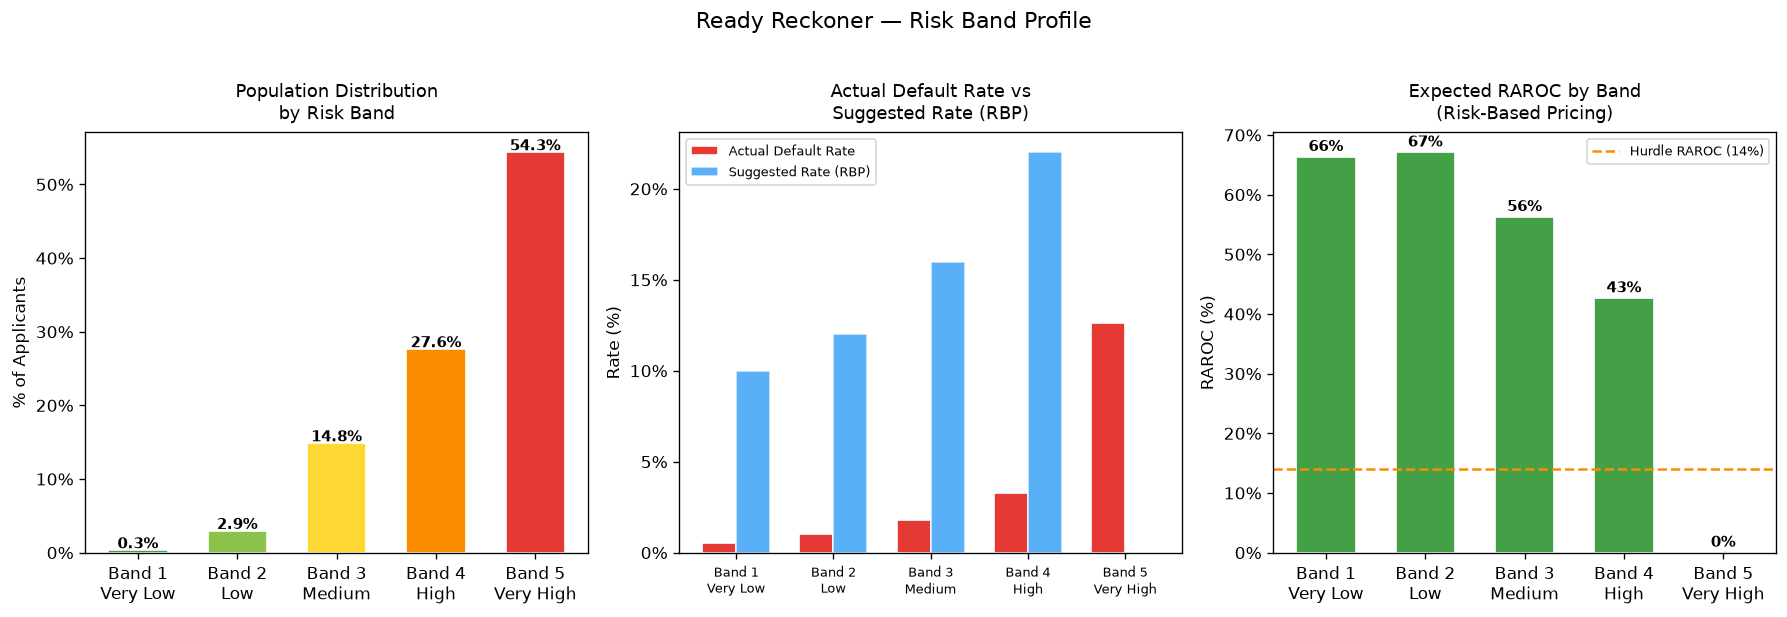

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

band_labels = [f"Band {int(r['Band'])}\n{r['Risk Category']}" for _, r in rr.iterrows()]
band_colors = [BAND_META[int(r['Band'])]["color"] for _, r in rr.iterrows()]

# Chart 1: Population share by band
axes[0].bar(band_labels, rr["Population %"] * 100, color=band_colors, edgecolor="white", width=0.6)
for ax_bar, val in zip(axes[0].patches, rr["Population %"].values):
    axes[0].text(ax_bar.get_x() + ax_bar.get_width()/2,
                 ax_bar.get_height() + 0.3,
                 f"{val:.1%}", ha="center", fontsize=9, fontweight="bold")
axes[0].set_title("Population Distribution\nby Risk Band", fontsize=11, pad=8)
axes[0].set_ylabel("% of Applicants")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# Chart 2: Actual default rate + suggested rate
x = np.arange(len(rr))
w = 0.35
axes[1].bar(x - w/2, rr["Actual Default %"] * 100, width=w, color="#E53935",
            label="Actual Default Rate", edgecolor="white")
rates_pct = [r * 100 if not np.isnan(r) else 0 for r in rr["Suggested Rate"]]
axes[1].bar(x + w/2, rates_pct, width=w, color="#2196F3",
            label="Suggested Rate (RBP)", edgecolor="white", alpha=0.75)
axes[1].set_xticks(x)
axes[1].set_xticklabels(band_labels, fontsize=8)
axes[1].set_title("Actual Default Rate vs\nSuggested Rate (RBP)", fontsize=11, pad=8)
axes[1].set_ylabel("Rate (%)")
axes[1].legend(fontsize=8)
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# Chart 3: Expected RAROC by band (RBP)
raroc_vals = [r if not np.isnan(r) else 0 for r in rr["Expected RAROC"]]
bar_colors_raroc = ["#43A047" if v > 0.14 else "#E53935" for v in raroc_vals]
axes[2].bar(band_labels, [v * 100 for v in raroc_vals], color=bar_colors_raroc,
            edgecolor="white", width=0.6)
axes[2].axhline(14, color="#FB8C00", lw=1.5, linestyle="--", label="Hurdle RAROC (14%)")
for bar, v in zip(axes[2].patches, raroc_vals):
    y = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 y + 1 if y >= 0 else y - 4,
                 f"{v:.0%}", ha="center", fontsize=9, fontweight="bold")
axes[2].set_title("Expected RAROC by Band\n(Risk-Based Pricing)", fontsize=11, pad=8)
axes[2].set_ylabel("RAROC (%)")
axes[2].legend(fontsize=8)
axes[2].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.0f}%"))

plt.suptitle("Ready Reckoner — Risk Band Profile", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Export as CSV

The Ready Reckoner is saved as a standalone CSV for use by credit operations teams,
relationship managers, or to load into the NirnayX decision engine.

In [4]:
export_cols = [
    "Band", "Risk Category", "PD Range", "Score Range",
    "Aggressive", "RAROC-Gated", "Risk-Based Pricing",
    "Suggested Rate", "Expected RAROC",
    "Population %", "Actual Default %", "Count"
]

rr_export = rr[export_cols].copy()
rr_export["Suggested Rate"]  = rr_export["Suggested Rate"].apply(
    lambda x: f"{x:.0%}" if not np.isnan(x) else "N/A"
)
rr_export["Expected RAROC"]  = rr_export["Expected RAROC"].apply(
    lambda x: f"{x:.1%}" if not np.isnan(x) else "N/A"
)
rr_export["Population %"]    = rr_export["Population %"].apply(lambda x: f"{x:.1%}")
rr_export["Actual Default %"]= rr_export["Actual Default %"].apply(lambda x: f"{x:.1%}")

rr_export.to_csv("../01_data/processed/ready_reckoner.csv", index=False)
print("Ready Reckoner saved: ../01_data/processed/ready_reckoner.csv")
print()
print(rr_export.to_string(index=False))

Ready Reckoner saved: ../01_data/processed/ready_reckoner.csv

 Band Risk Category PD Range Score Range Aggressive RAROC-Gated Risk-Based Pricing Suggested Rate Expected RAROC Population % Actual Default %  Count
    1      Very Low     0–5%         N/A    APPROVE     APPROVE            APPROVE            10%          66.3%         0.3%             0.5%    182
    2           Low    5–10%         N/A    APPROVE     APPROVE            APPROVE            12%          67.1%         2.9%             1.0%   1798
    3        Medium   10–20%         N/A    APPROVE     APPROVE            APPROVE            16%          56.3%        14.8%             1.8%   9120
    4          High   20–35%         N/A    APPROVE     DECLINE            APPROVE            22%          42.6%        27.6%             3.3%  16979
    5     Very High     >35%         N/A    DECLINE     DECLINE            DECLINE            N/A            N/A        54.3%            12.6%  33424


---
## 4. How to Use the Ready Reckoner

### For a Credit Operations Officer

1. Run the borrower's application through the XGBoost model to get a PD score
2. Look up the corresponding Risk Band (1–5) from the scorecard or PD threshold
3. Read across the row for the active lending strategy:
   - **Aggressive**: approve all Band 1–4 borrowers at standard rate
   - **RAROC-Gated**: approve only Band 1–2 (RAROC > hurdle); decline 3–5
   - **Risk-Based Pricing**: approve Band 1–4 at the band-specific suggested rate

### For a Pricing Manager

The `Suggested Rate` column gives the band-specific rate derived from the risk-based
pricing model that achieves the target RAROC. Rates are set to cover:

```
Rate = Cost of Funds + Expected Loss (PD x LGD) + Operating Cost + Target Spread
```

### For a Risk Committee

The `Expected RAROC` column shows the risk-adjusted return achievable per band
under the risk-based pricing strategy. Bands where Expected RAROC < 14% (the hurdle)
are value-destructive at standard rates — they require repricing or declination.

### Refresh Cadence

Re-run this notebook after any model recalibration or rate update. The PSI and CSI
monitoring triggers in `05_governance/monitoring_triggers.py` will flag when the
underlying score distribution has shifted enough to warrant a Ready Reckoner refresh.